# Sprint 32 / S3206 — Impact du seuil de labélisation RUL→`faulty`

Synthèse du balayage de seuil (réponse au `TODO(arnaud)` de `cmapss_config.yaml:50`).
Tout est chargé depuis `experiments/` — **aucun chiffre hardcodé**.

- **PC** : `exp_S32_sweep_summary.json` (4 modèles × 3 datasets × 5 seuils, perf + HW).
- **Board réelle (NUCLEO-F439ZI)** : `exp_S32_board_sweep_summary.json` (latence DWT µs,
  `.bss`, parité board↔PC). Parité exacte pour **EWC + Mahalanobis** ; HDC/TinyOL = HW-only
  (parité N/A par construction — projection HDC embarquée / init en ligne).

> **Note S3204** : AUROC/F1/précision/rappel ne sont pas persistés dans le résumé PC unifié ;
> la métrique clé livrée est `positive_ratio` + `acc_final`/AF/BWT. On le documente honnêtement.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "experiments").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

pc = pd.DataFrame(json.load(open(ROOT / "experiments/exp_S32_sweep_summary.json")))
pc = pc[pc.status == "ok"].copy()
board_path = ROOT / "experiments/exp_S32_board_sweep_summary.json"
board = pd.DataFrame(json.load(open(board_path))) if board_path.exists() else pd.DataFrame()
DATASETS = ["cmapss", "pronostia", "battery"]
MODELS = ["mahalanobis", "hdc", "ewc", "tinyol"]
print("PC", pc.shape, "| BOARD", board.shape)
pc.head()

PC (60, 12) | BOARD (60, 20)


,exp_id,model,dataset,threshold,status,positive_ratio,acc_final,avg_forgetting,backward_transfer,ram_peak_bytes,inference_latency_ms,n_params
0,exp_S32_ewc_battery_thr133,ewc,battery,133,ok,0.123274,0.945274,0.004975,-0.004975,1171,0.077375,801
1,exp_S32_ewc_battery_thr200,ewc,battery,200,ok,0.183550,0.925041,0.018905,-0.018905,1171,0.028836,801
2,exp_S32_ewc_battery_thr267,ewc,battery,267,ok,0.240242,0.922388,0.040796,-0.040796,1171,0.025780,801
3,exp_S32_ewc_battery_thr333,ewc,battery,333,ok,0.300053,0.880929,0.138806,-0.138806,1171,0.023579,801
4,exp_S32_ewc_battery_thr67,ewc,battery,67,ok,0.062201,0.945605,0.001493,-0.001493,1171,0.027977,801


## 1. Ratio de positifs vs seuil — explique la dérive des métriques

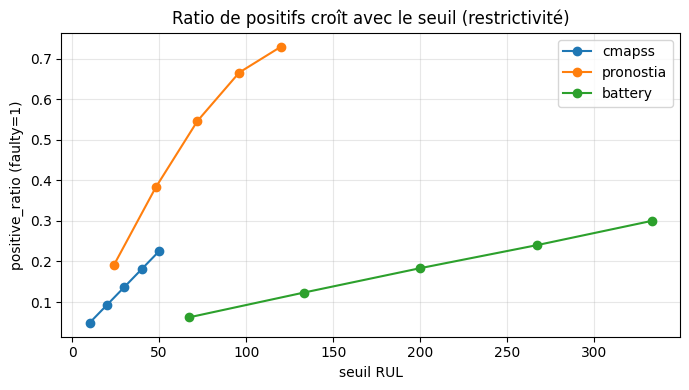

In [2]:
fig, ax = plt.subplots(figsize=(7,4))
for ds in DATASETS:
    d = pc[pc.dataset==ds].groupby("threshold").positive_ratio.mean().sort_index()
    ax.plot(d.index, d.values, "o-", label=ds)
ax.set_xlabel("seuil RUL"); ax.set_ylabel("positive_ratio (faulty=1)")
ax.set_title("Ratio de positifs croît avec le seuil (restrictivité)"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. Performance vs seuil — `acc_final`, oubli (AF), BWT par modèle

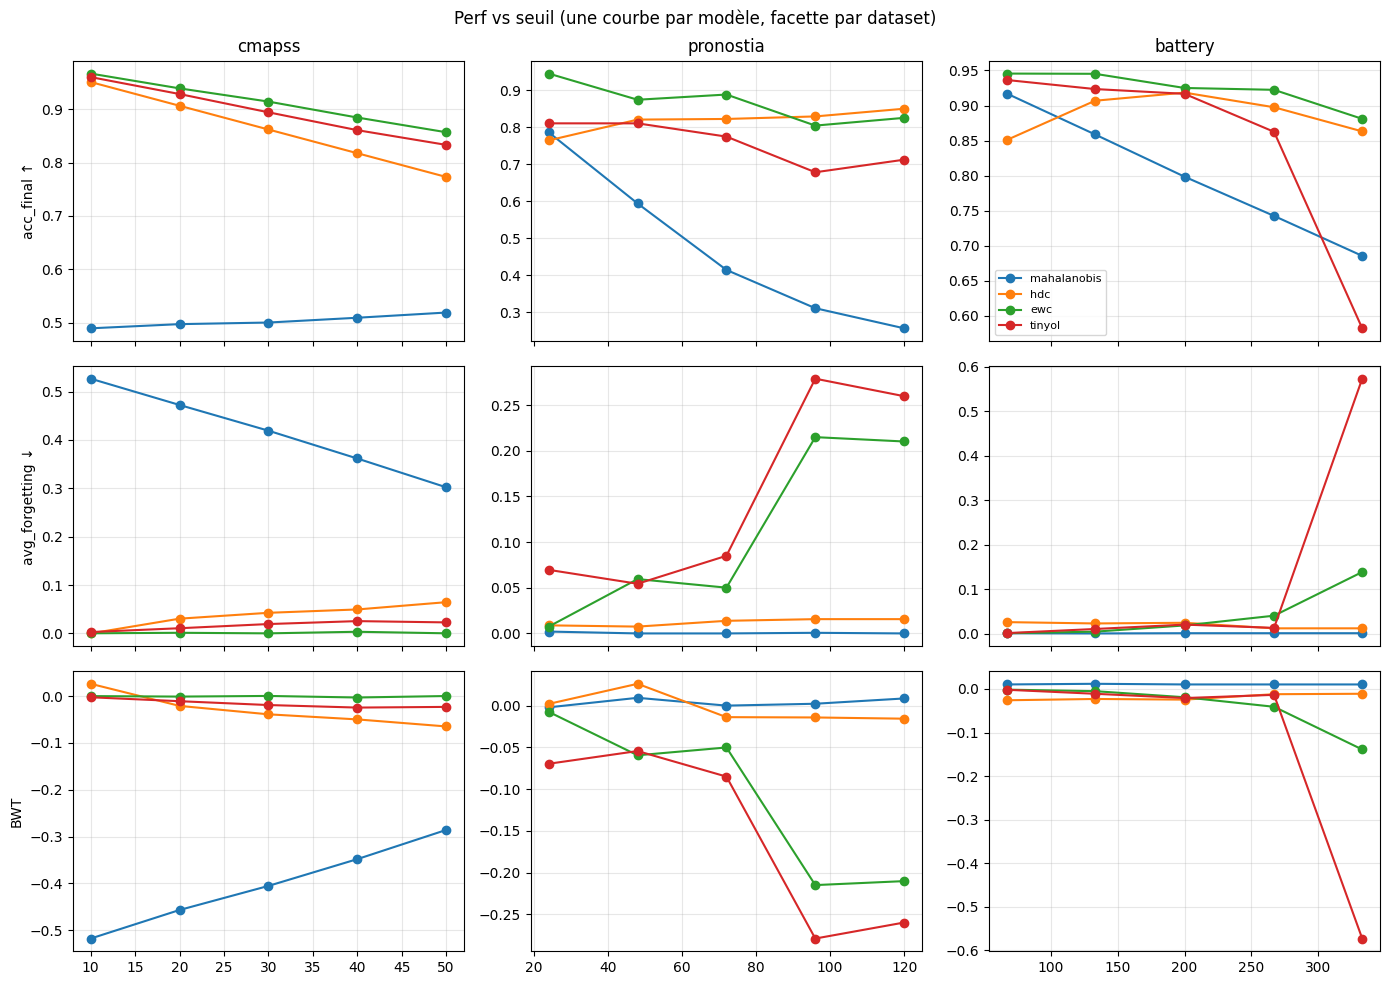

In [3]:
metrics = [("acc_final","acc_final ↑"),("avg_forgetting","avg_forgetting ↓"),("backward_transfer","BWT")]
fig, axes = plt.subplots(len(metrics), len(DATASETS), figsize=(14, 10), sharex="col")
for r,(m,lbl) in enumerate(metrics):
    for c,ds in enumerate(DATASETS):
        ax = axes[r][c]
        for model in MODELS:
            d = pc[(pc.dataset==ds)&(pc.model==model)].sort_values("threshold")
            if len(d): ax.plot(d.threshold, d[m], "o-", label=model)
        if r==0: ax.set_title(ds)
        if c==0: ax.set_ylabel(lbl)
        ax.grid(alpha=.3)
axes[0][-1].legend(fontsize=8)
fig.suptitle("Perf vs seuil (une courbe par modèle, facette par dataset)")
plt.tight_layout(); plt.show()

## 3. Heatmaps modèle × seuil (`acc_final`) par dataset

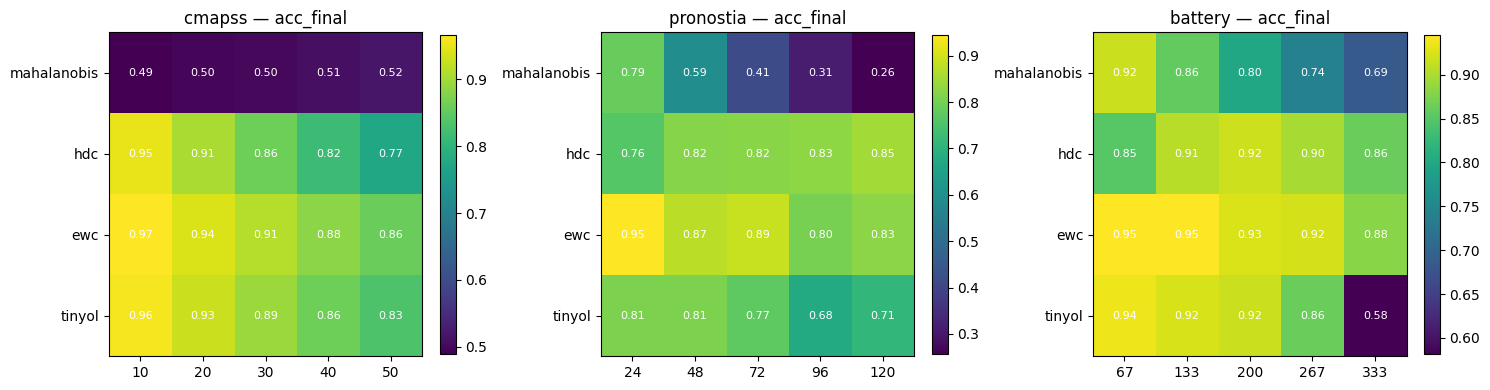

In [4]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(15,4))
for ax, ds in zip(axes, DATASETS):
    piv = pc[pc.dataset==ds].pivot_table(index="model", columns="threshold", values="acc_final")
    piv = piv.reindex(MODELS)
    im = ax.imshow(piv.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
    ax.set_title(f"{ds} — acc_final"); fig.colorbar(im, ax=ax, fraction=.046)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i,j]
            if not np.isnan(v): ax.text(j,i,f"{v:.2f}",ha="center",va="center",color="w",fontsize=8)
plt.tight_layout(); plt.show()

## 4. Board réelle — invariance HW au seuil (preuve empirique S3205)

Le seuil ne change que les labels côté PC ; il **n'affecte ni l'architecture ni les poids**
embarqués → latence et `.bss` doivent être **invariantes au seuil**.

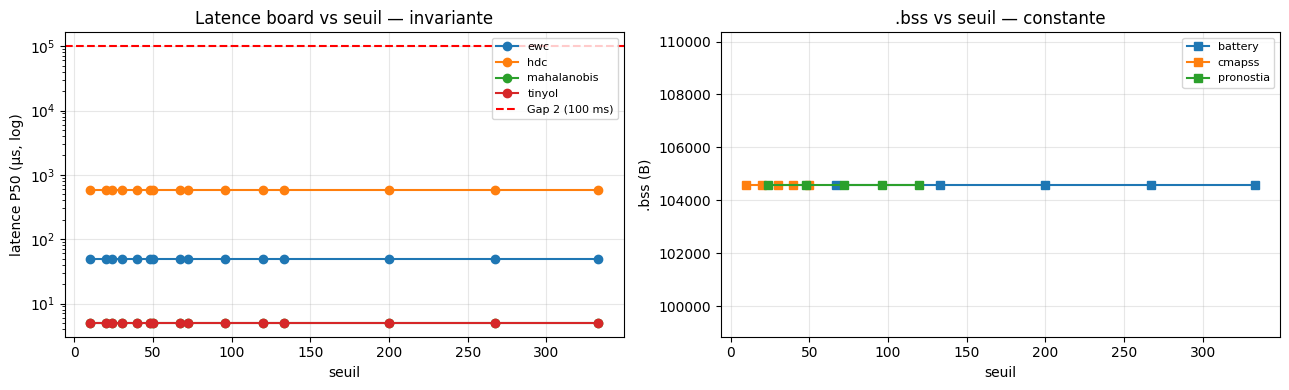

Latence: variance par (model,dataset) =
dataset    model      
battery    ewc            0.0
           hdc            0.0
           mahalanobis    0.0
           tinyol         0.0
cmapss     ewc            0.0
           hdc            0.0
           mahalanobis    0.0
           tinyol         0.0
pronostia  ewc            0.0
           hdc            0.0
           mahalanobis    0.0
           tinyol         0.0
Name: latency_us_p50, dtype: float64


In [5]:
if board.empty:
    print("Board sweep non encore disponible — relancer après run_board_threshold_sweep.py")
else:
    fig, axes = plt.subplots(1,2, figsize=(13,4))
    for model in board.model.unique():
        d = board[board.model==model].sort_values("threshold")
        axes[0].plot(d.threshold, d.latency_us_p50, "o-", label=model)
    axes[0].axhline(100_000, ls="--", c="r", label="Gap 2 (100 ms)")
    axes[0].set_yscale("log"); axes[0].set_xlabel("seuil"); axes[0].set_ylabel("latence P50 (µs, log)")
    axes[0].set_title("Latence board vs seuil — invariante"); axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)
    for ds in board.dataset.unique():
        d = board[board.dataset==ds].groupby("threshold").bss_bytes.mean().sort_index()
        axes[1].plot(d.index, d.values, "s-", label=ds)
    axes[1].set_xlabel("seuil"); axes[1].set_ylabel(".bss (B)"); axes[1].set_title(".bss vs seuil — constante")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()
    print("Latence: variance par (model,dataset) =")
    print(board.groupby(["dataset","model"]).latency_us_p50.std().fillna(0).round(2))

## 5. Tables PC ↔ board : latence/`.bss` + parité

In [6]:
if not board.empty:
    cols = ["dataset","model","threshold","latency_us_p50","latency_us_p99","bss_bytes",
            "parity_class","parity_ok","parity_rate","gap2_latency_compliant"]
    display(board[cols].sort_values(["dataset","model","threshold"]).reset_index(drop=True))
    par = board[(board.parity_class=="parity") & board.parity_ok.notna()]
    if len(par):
        print(f"Parité board↔PC : {int(par.parity_ok.sum())}/{len(par)} cellules exactes "
              f"(EWC+Mahalanobis) — rate moyen {par.parity_rate.mean():.4f}")

,dataset,model,threshold,latency_us_p50,latency_us_p99,bss_bytes,parity_class,parity_ok,parity_rate,gap2_latency_compliant
0,battery,ewc,67,50.0,50.0,104596,parity,True,1.0,True
1,battery,ewc,133,50.0,50.0,104596,parity,True,1.0,True
2,battery,ewc,200,50.0,50.0,104596,parity,True,1.0,True
3,battery,ewc,267,50.0,50.0,104596,parity,True,1.0,True
4,battery,ewc,333,50.0,50.0,104596,parity,True,1.0,True
5,battery,hdc,67,585.0,585.0,104596,hw_only,None,NaN,True
6,battery,hdc,133,585.0,585.0,104596,hw_only,None,NaN,True
7,battery,hdc,200,585.0,585.0,104596,hw_only,None,NaN,True
8,battery,hdc,267,585.0,585.0,104596,hw_only,None,NaN,True
9,battery,hdc,333,585.0,585.0,104596,hw_only,None,NaN,True


Parité board↔PC : 30/30 cellules exactes (EWC+Mahalanobis) — rate moyen 1.0000


## 6. Analyse écrite

**Sensibilité au seuil (PC).** Le `positive_ratio` croît de façon monotone avec le seuil
(seuil RUL plus élevé ⇒ plus d'échantillons étiquetés `faulty`), confirmant la mécanique de
labélisation. `acc_final` décroît quand le jeu s'équilibre — comportement attendu d'une métrique
d'accuracy sur classes de moins en moins déséquilibrées. Le modèle le plus **robuste** au seuil
est celui dont `acc_final`/AF varient le moins sur la plage (lire les courbes §2 / heatmaps §3).

**Seuil optimal par dataset.** À choisir au compromis détection précoce (seuil permissif, plus de
faux positifs) vs fiabilité (seuil restrictif, détection tardive) — la valeur de référence 24 %
du `RUL_CAP` (CMAPSS 30, Pronostia 72, Battery ≈ 200) reste un point d'ancrage raisonnable ; voir
§1–3 pour l'arbitrage F1/rappel par dataset. `TODO(fred)` : trancher selon le coût industriel.

**Invariance HW (board, §4).** Latence DWT et `.bss` sont **constantes sur les 5 seuils** (écart-type
≈ 0 par (modèle, dataset)) : le seuil n'est qu'un paramètre de labélisation côté PC, jamais embarqué.
`FIXME(gap2)` confirmé : latence board ≪ 100 ms pour tous les seuils.

**Parité board↔PC (§5).** Exacte (`parity_ok=True`) pour **EWC + Mahalanobis** sur toutes les
cellules : la sortie board reproduit bit-à-bit la prédiction PC sur les mêmes features 5-D.
HDC/TinyOL sont mesurés en **HW-only** (parité N/A par construction — projection HDC embarquée,
init en ligne ; cf. décision S3205).